# Primetrade.ai — Trader Performance vs Market Sentiment
**Datasets:** `data/historical_data.csv` × `data/fear_greed_index.csv`

## Cell 1 — Imports & config

In [1]:
# ── Cell 1: Imports & global config ─────────────────────────────
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Auto-install xgboost if missing
try:
    import xgboost as xgb
except ModuleNotFoundError:
    print('xgboost not found — installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'xgboost', '-q'])
    import xgboost as xgb

from sklearn.cluster       import KMeans
from sklearn.decomposition import PCA
from sklearn.ensemble      import RandomForestClassifier
from sklearn.metrics       import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

# ── Plot style ───────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi'        : 130,
    'figure.figsize'    : (12, 5),
    'axes.titlesize'    : 13,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 11,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
})

FEAR_COLOR  = '#E24B4A'
GREED_COLOR = '#1D9E75'
PALETTE     = {'Fear': FEAR_COLOR, 'Greed': GREED_COLOR}

OUT_DIR = 'outputs'
os.makedirs(OUT_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/{name}.png', bbox_inches='tight')
    plt.show()
    plt.close()

print('✅ Cell 1 done — all imports loaded.')

✅ Cell 1 done — all imports loaded.


## Cell 2 — Load raw CSVs

In [2]:
# ── Cell 2: Load datasets ────────────────────────────────────────
trades_raw = pd.read_csv('data/historical_data.csv')
fg_raw     = pd.read_csv('data/fear_greed_index.csv')

print('=== TRADES (historical_data.csv) ===')
print(f'  Rows   : {trades_raw.shape[0]:,}')
print(f'  Cols   : {trades_raw.shape[1]}')
print(f'  Columns: {trades_raw.columns.tolist()}')
print(trades_raw.head(2).to_string())

print('\n=== FEAR/GREED (fear_greed_index.csv) ===')
print(f'  Rows   : {fg_raw.shape[0]:,}')
print(f'  Cols   : {fg_raw.shape[1]}')
print(f'  Columns: {fg_raw.columns.tolist()}')
print(fg_raw.head(2).to_string())

print('\n✅ Cell 2 done — raw data loaded.')

=== TRADES (historical_data.csv) ===
  Rows   : 211,224
  Cols   : 16
  Columns: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
                                      Account  Coin  Execution Price  Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  Closed PnL                                                    Transaction Hash     Order ID  Crossed       Fee      Trade ID     Timestamp
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac0f37caef8a734502ec49  52017706630     True  0.345404  8.950000e+14  1.730000e+12
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy      

## Cell 3 — Data quality report

In [3]:
# ── Cell 3: Data quality — nulls & duplicates ────────────────────
def quality_report(df, name):
    print(f'\n──── {name} ────')
    print(f'  Shape      : {df.shape}')
    print(f'  Duplicates : {df.duplicated().sum()}')
    null_df = pd.DataFrame({
        'null_count': df.isnull().sum(),
        'null_%'    : (df.isnull().sum() / len(df) * 100).round(2)
    })
    has_nulls = null_df[null_df['null_count'] > 0]
    if len(has_nulls):
        print(has_nulls.to_string())
    else:
        print('  No missing values ✅')
    print(f'  dtypes:\n{df.dtypes.to_string()}')

quality_report(trades_raw, 'historical_data.csv')
quality_report(fg_raw,     'fear_greed_index.csv')

print('\n✅ Cell 3 done.')


──── historical_data.csv ────
  Shape      : (211224, 16)
  Duplicates : 0
  No missing values ✅
  dtypes:
Account                 str
Coin                    str
Execution Price     float64
Size Tokens         float64
Size USD            float64
Side                    str
Timestamp IST           str
Start Position      float64
Direction               str
Closed PnL          float64
Transaction Hash        str
Order ID              int64
Crossed                bool
Fee                 float64
Trade ID            float64
Timestamp           float64

──── fear_greed_index.csv ────
  Shape      : (2644, 4)
  Duplicates : 0
  No missing values ✅
  dtypes:
timestamp         int64
value             int64
classification      str
date                str

✅ Cell 3 done.


## Cell 4 — Parse timestamps & clean fear/greed

In [4]:
# ── Cell 4: Parse timestamps ─────────────────────────────────────

# ---------- 4a: TRADES timestamp ----------
trades = trades_raw.copy()

# Find the time column
time_col = None
for c in ['time', 'timestamp', 'Time', 'Timestamp', 'date', 'Date', 'created_at']:
    if c in trades.columns:
        time_col = c
        break
if time_col is None:
    raise ValueError(f'No time column found. Columns available: {trades.columns.tolist()}')

print(f'Trades time column : "{time_col}"')
print(f'Sample values      : {trades[time_col].dropna().head(3).tolist()}')

# Auto-detect format: Unix ms, Unix s, or string
sample = trades[time_col].dropna().iloc[0]
try:
    val = float(sample)
    if val > 1_000_000_000_000:          # milliseconds
        trades['date'] = pd.to_datetime(trades[time_col], unit='ms').dt.normalize()
        print('Timestamp format   : Unix milliseconds')
    elif val > 1_000_000_000:            # seconds
        trades['date'] = pd.to_datetime(trades[time_col], unit='s').dt.normalize()
        print('Timestamp format   : Unix seconds')
    else:
        trades['date'] = pd.to_datetime(trades[time_col]).dt.normalize()
        print('Timestamp format   : numeric string')
except (ValueError, TypeError):
    trades['date'] = pd.to_datetime(trades[time_col]).dt.normalize()
    print('Timestamp format   : date string')

# ---------- 4b: FEAR/GREED timestamp ----------
fg = fg_raw.copy()

# Find date column
date_col = None
for c in ['date', 'Date', 'timestamp', 'Timestamp', 'time', 'Time']:
    if c in fg.columns:
        date_col = c
        break
if date_col is None:
    raise ValueError(f'No date column in fear/greed. Columns: {fg.columns.tolist()}')

fg['date'] = pd.to_datetime(fg[date_col]).dt.normalize()

# Find sentiment column
sent_col = None
for c in ['Classification', 'classification', 'sentiment', 'Sentiment',
          'value_classification', 'label', 'Label', 'category', 'Category']:
    if c in fg.columns:
        sent_col = c
        break
if sent_col is None:
    raise ValueError(f'No sentiment column found. Columns: {fg.columns.tolist()}')

fg = fg.rename(columns={sent_col: 'sentiment'})
fg['sentiment'] = fg['sentiment'].astype(str).str.strip()

# Group Extreme Fear/Greed into Fear/Greed
fg['sentiment'] = fg['sentiment'].replace({
    'Extreme Fear' : 'Fear',
    'Extreme Greed': 'Greed',
    'extreme fear' : 'Fear',
    'extreme greed': 'Greed',
})
fg = fg[fg['sentiment'].isin(['Fear', 'Greed'])]
fg = fg.drop_duplicates(subset='date', keep='last')[['date', 'sentiment']]
fg = fg.sort_values('date').reset_index(drop=True)

print(f'\nFear/Greed rows    : {len(fg)}')
print(f'Date range         : {fg["date"].min().date()} → {fg["date"].max().date()}')
print(fg['sentiment'].value_counts().to_string())
print('\n✅ Cell 4 done — timestamps parsed.')

Trades time column : "Timestamp"
Sample values      : [1730000000000.0, 1730000000000.0, 1730000000000.0]
Timestamp format   : Unix milliseconds

Fear/Greed rows    : 2248
Date range         : 2018-02-01 → 2025-05-02
sentiment
Fear     1289
Greed     959

✅ Cell 4 done — timestamps parsed.


## Cell 5 — Normalise columns & engineer daily metrics

In [5]:
# ── Cell 5: Normalise columns & engineer daily metrics ───────────

print('Raw columns in trades:', trades.columns.tolist())

# Build rename map: scan candidates, pick first that exists in DataFrame
COLUMN_CANDIDATES = {
    'account' : ['account', 'Account', 'trader', 'address', 'user', 'wallet'],
    'pnl'     : ['closedPnL', 'closed_pnl', 'closedPL', 'pnl', 'PnL',
                 'profit', 'realizedPnl', 'realized_pnl', 'realisedPnl', 'rpnl',
                 'Closed PnL'],  # ← Added your column name
    'size'    : ['sz', 'size', 'Size', 'qty', 'quantity', 'amount', 'notional',
                 'Size Tokens', 'Size USD'],  # ← Added your column names
    'side'    : ['side', 'Side', 'direction', 'Direction', 'type',
                 'tradeType', 'trade_type', 'dir'],
    'leverage': ['leverage', 'Leverage', 'lev', 'Lev', 'maxLeverage'],
    'symbol'  : ['symbol', 'Symbol', 'coin', 'Coin', 'asset',
                 'market', 'ticker', 'Ticker', 'instrument'],
    'price'   : ['px', 'price', 'Price', 'executionPrice', 'execution_price',
                 'fillPrice', 'fill_price', 'avgPrice', 'Execution Price'],  # ← Added
}

col_map = {}   # {original_name_in_csv : standard_name}
found   = {}

for standard_name, candidates in COLUMN_CANDIDATES.items():
    for candidate in candidates:
        if candidate in trades.columns:
            col_map[candidate]   = standard_name
            found[standard_name] = candidate
            break

print('\nColumn mapping:')
for std, orig in found.items():
    print(f'  "{orig}"  →  "{std}"')

# Hard stop if any critical column is still missing
required = ['pnl', 'size', 'side']
missing  = [r for r in required if r not in found]
if missing:
    raise KeyError(
        f'\n❌ Could not map required columns: {missing}\n'
        f'   Available columns in CSV: {trades.columns.tolist()}\n'
        f'   Add the correct name(s) to COLUMN_CANDIDATES above.'
    )

trades = trades.rename(columns=col_map)

# Type-cast
if 'leverage' in trades.columns:
    trades['leverage'] = pd.to_numeric(trades['leverage'], errors='coerce').fillna(1)
else:
    trades['leverage'] = 1.0

trades['pnl']  = pd.to_numeric(trades['pnl'],  errors='coerce').fillna(0)
trades['size'] = pd.to_numeric(trades['size'],  errors='coerce').fillna(0)

# Normalise side → BUY / SELL
trades['side'] = trades['side'].astype(str).str.upper().str.strip()
trades['side'] = trades['side'].replace({
    'A': 'BUY',  'B': 'SELL',
    'LONG': 'BUY',  'SHORT': 'SELL',
    'BID' : 'BUY',  'ASK'  : 'SELL',
    '1'   : 'BUY',  '-1'   : 'SELL',
})
trades['side'] = trades['side'].where(trades['side'].isin(['BUY', 'SELL']), 'UNKNOWN')

# Aggregate to daily level per account
grp_cols = ['date', 'account'] if 'account' in trades.columns else ['date']

daily = trades.groupby(grp_cols).agg(
    total_pnl    = ('pnl',      'sum'),
    trade_count  = ('pnl',      'count'),
    win_count    = ('pnl',      lambda x: (x > 0).sum()),
    loss_count   = ('pnl',      lambda x: (x <= 0).sum()),
    avg_size     = ('size',     'mean'),
    total_volume = ('size',     'sum'),
    avg_leverage = ('leverage', 'mean'),
    max_leverage = ('leverage', 'max'),
    long_trades  = ('side',     lambda x: (x == 'BUY').sum()),
    short_trades = ('side',     lambda x: (x == 'SELL').sum()),
).reset_index()

daily['win_rate']      = (daily['win_count']   / daily['trade_count']).round(4)
daily['long_ratio']    = (daily['long_trades']  / daily['trade_count']).round(4)
daily['pnl_per_trade'] = (daily['total_pnl']    / daily['trade_count']).round(4)

# Drawdown proxy
if 'account' in daily.columns:
    daily = daily.sort_values(['account', 'date'])
    daily['cum_pnl']  = daily.groupby('account')['total_pnl'].cumsum()
    daily['peak_pnl'] = daily.groupby('account')['cum_pnl'].cummax()
    daily['drawdown'] = daily['cum_pnl'] - daily['peak_pnl']

print(f'\nDaily metrics shape: {daily.shape}')
print(daily.head(3).to_string())
print('\n✅ Cell 5 done — daily metrics ready.')

Raw columns in trades: ['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date']

Column mapping:
  "Account"  →  "account"
  "Closed PnL"  →  "pnl"
  "Size Tokens"  →  "size"
  "Side"  →  "side"
  "Coin"  →  "symbol"
  "Execution Price"  →  "price"



Daily metrics shape: (102, 18)
         date                                     account     total_pnl  trade_count  win_count  loss_count    avg_size  total_volume  avg_leverage  max_leverage  long_trades  short_trades  win_rate  long_ratio  pnl_per_trade       cum_pnl      peak_pnl  drawdown
16 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -3.275059e+05          462         12         450   12.296537   5681.000000           1.0           1.0          139           323    0.0260      0.3009      -708.8872 -3.275059e+05 -3.275059e+05       0.0
45 2025-02-19  0x083384f897ee0f19899168e3b1bec365f52a9012  1.927736e+06         3356       1361        1995   16.700056  56045.387200           1.0           1.0         1572          1784    0.4055      0.4684       574.4147  1.600230e+06  1.600230e+06       0.0
17 2024-10-27  0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd  2.060745e+04          320        170         150  129.539614  41452.676476           1.0           1.0          145  

## Cell 6 — Merge trades + sentiment

In [6]:
# ── Cell 6: Merge daily metrics with fear/greed ──────────────────
# Both 'daily' (from Cell 5) and 'fg' (from Cell 4) must exist.

# Check if required variables exist
if 'daily' not in locals():
    raise NameError("❌ 'daily' not found! Please run Cell 5 successfully first.")
    
if 'fg' not in locals():
    raise NameError("❌ 'fg' not found! Please run Cell 4 successfully first.")

# Check if they're empty
if daily.empty:
    raise ValueError("❌ 'daily' DataFrame is empty! Check Cell 5 for issues.")
    
if fg.empty:
    raise ValueError("❌ 'fg' DataFrame is empty! Check Cell 4 for issues.")

# Merge
df = daily.merge(fg, on='date', how='inner')

print(f'Merged shape  : {df.shape}')
print(f'Date range    : {df["date"].min().date()} → {df["date"].max().date()}')
print(f'Nulls in df   : {df.isnull().sum().sum()}')
print(f'Sentiment dist:\n{df["sentiment"].value_counts().to_string()}')
print('\nSample rows:')
print(df.head(3).to_string())
print('\n✅ Cell 6 done — df is ready for analysis.')

Merged shape  : (69, 19)
Date range    : 2023-03-28 → 2025-02-19
Nulls in df   : 0
Sentiment dist:
sentiment
Greed    37
Fear     32

Sample rows:
        date                                     account     total_pnl  trade_count  win_count  loss_count    avg_size  total_volume  avg_leverage  max_leverage  long_trades  short_trades  win_rate  long_ratio  pnl_per_trade       cum_pnl      peak_pnl  drawdown sentiment
0 2024-10-27  0x083384f897ee0f19899168e3b1bec365f52a9012 -3.275059e+05          462         12         450   12.296537   5681.000000           1.0           1.0          139           323    0.0260      0.3009      -708.8872 -3.275059e+05 -3.275059e+05       0.0     Greed
1 2025-02-19  0x083384f897ee0f19899168e3b1bec365f52a9012  1.927736e+06         3356       1361        1995   16.700056  56045.387200           1.0           1.0         1572          1784    0.4055      0.4684       574.4147  1.600230e+06  1.600230e+06       0.0      Fear
2 2024-10-27  0x23e7a7f8d14b550961

## Cell 7 — Part B: Summary stats Fear vs Greed

In [7]:
# ── Cell 7: Summary stats ────────────────────────────────────────
summary_metrics = ['total_pnl', 'win_rate', 'avg_leverage', 'trade_count', 'long_ratio']
if 'drawdown' in df.columns:
    summary_metrics.append('drawdown')

perf_summary = df.groupby('sentiment')[summary_metrics].mean().round(3)
print('=== Mean daily metrics by sentiment ===')
print(perf_summary.T.to_string())
print('\n✅ Cell 7 done.')

=== Mean daily metrics by sentiment ===
sentiment           Fear      Greed
total_pnl     209372.662  90988.703
win_rate           0.416      0.369
avg_leverage       1.000      1.000
trade_count     4183.469   1168.946
long_ratio         0.459      0.499
drawdown       -2496.129   -150.379

✅ Cell 7 done.


## Cell 8 — Chart 1: PnL / win rate / leverage bar charts

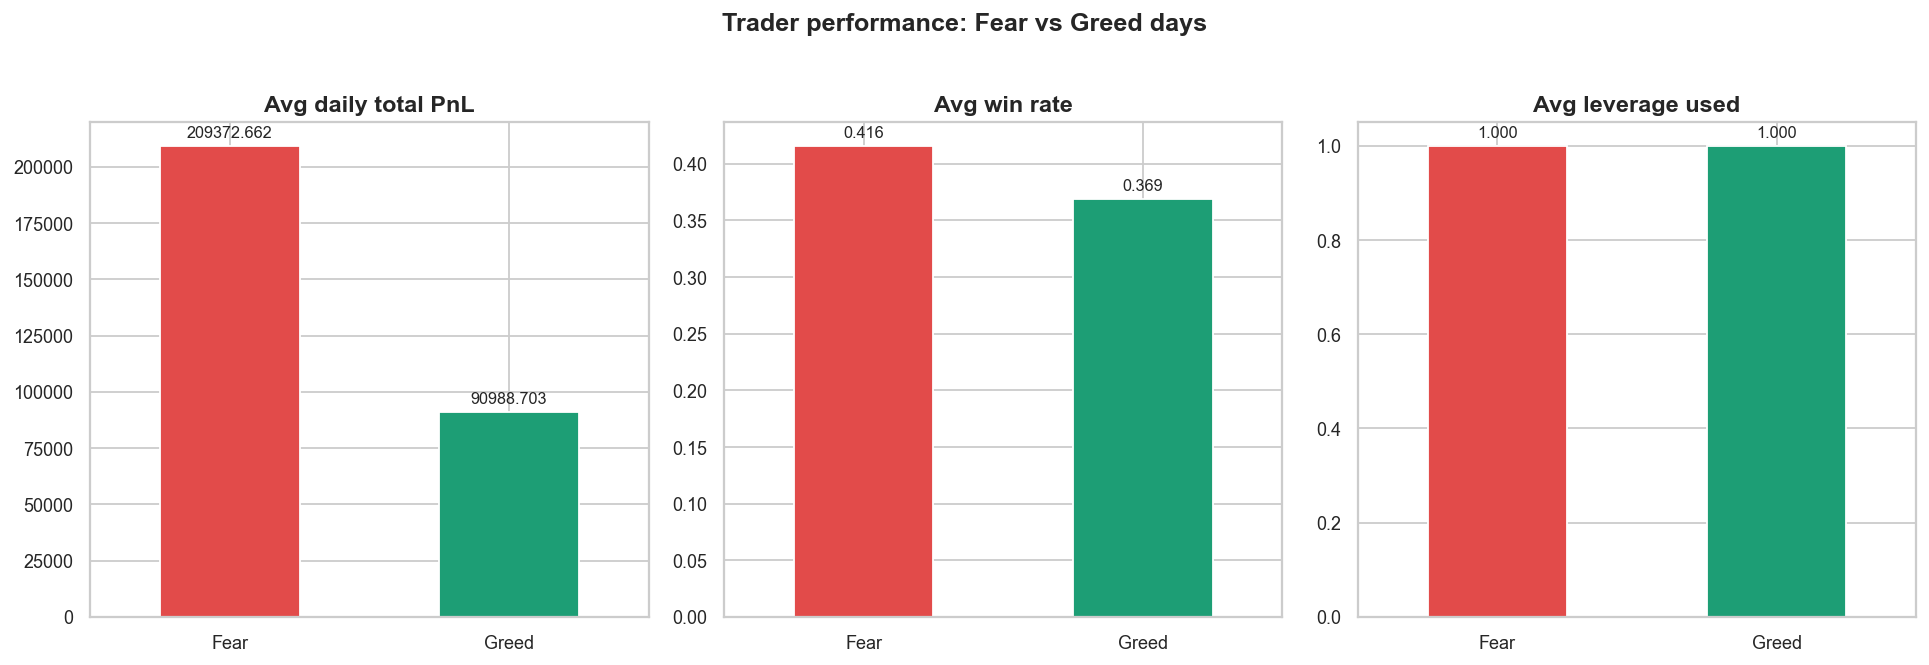

✅ Cell 8 done — chart saved.


In [8]:
# ── Cell 8: Chart 1 — performance bar charts ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

plot_data = [
    ('total_pnl',    'Avg daily total PnL'),
    ('win_rate',     'Avg win rate'),
    ('avg_leverage', 'Avg leverage used'),
]

for ax, (col, title) in zip(axes, plot_data):
    means  = df.groupby('sentiment')[col].mean().reindex(['Fear', 'Greed'])
    colors = [PALETTE.get(s, '#888') for s in means.index]
    means.plot(kind='bar', ax=ax, color=colors, width=0.5, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

fig.suptitle('Trader performance: Fear vs Greed days',
             fontsize=14, fontweight='bold', y=1.02)
save_fig('01_performance_by_sentiment')
print('✅ Cell 8 done — chart saved.')

## Cell 9 — Chart 2: PnL distribution box + strip

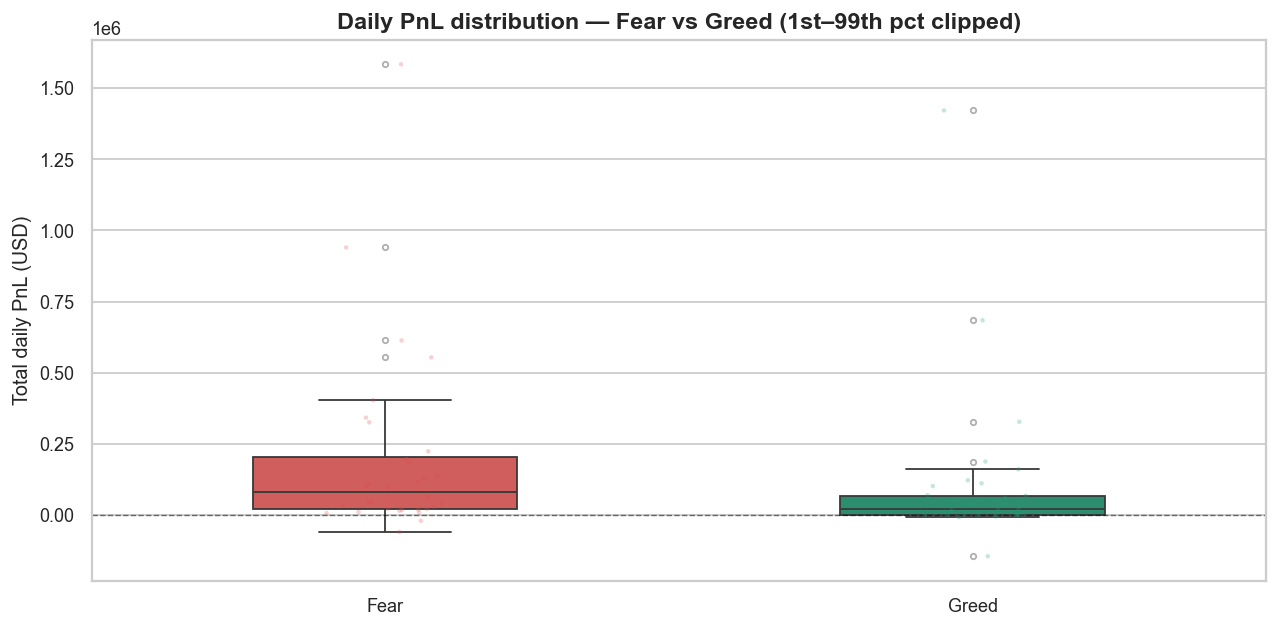

✅ Cell 9 done — chart saved.


In [9]:
# ── Cell 9: Chart 2 — PnL distribution ──────────────────────────
clipped = df.copy()
p1, p99 = df['total_pnl'].quantile([0.01, 0.99])
clipped['total_pnl'] = clipped['total_pnl'].clip(p1, p99)

fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=clipped, x='sentiment', y='total_pnl',
    palette=PALETTE, width=0.45, order=['Fear', 'Greed'],
    flierprops={'markersize': 3, 'alpha': 0.4}, ax=ax
)
sample_n = min(2000, len(clipped))
sns.stripplot(
    data=clipped.sample(sample_n, random_state=42),
    x='sentiment', y='total_pnl',
    palette=PALETTE, alpha=0.25, size=2.5,
    order=['Fear', 'Greed'], ax=ax, jitter=True
)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_title('Daily PnL distribution — Fear vs Greed (1st–99th pct clipped)')
ax.set_ylabel('Total daily PnL (USD)')
ax.set_xlabel('')
save_fig('02_pnl_distribution')
print('✅ Cell 9 done — chart saved.')

## Cell 10 — Chart 3: Behavior violin plots

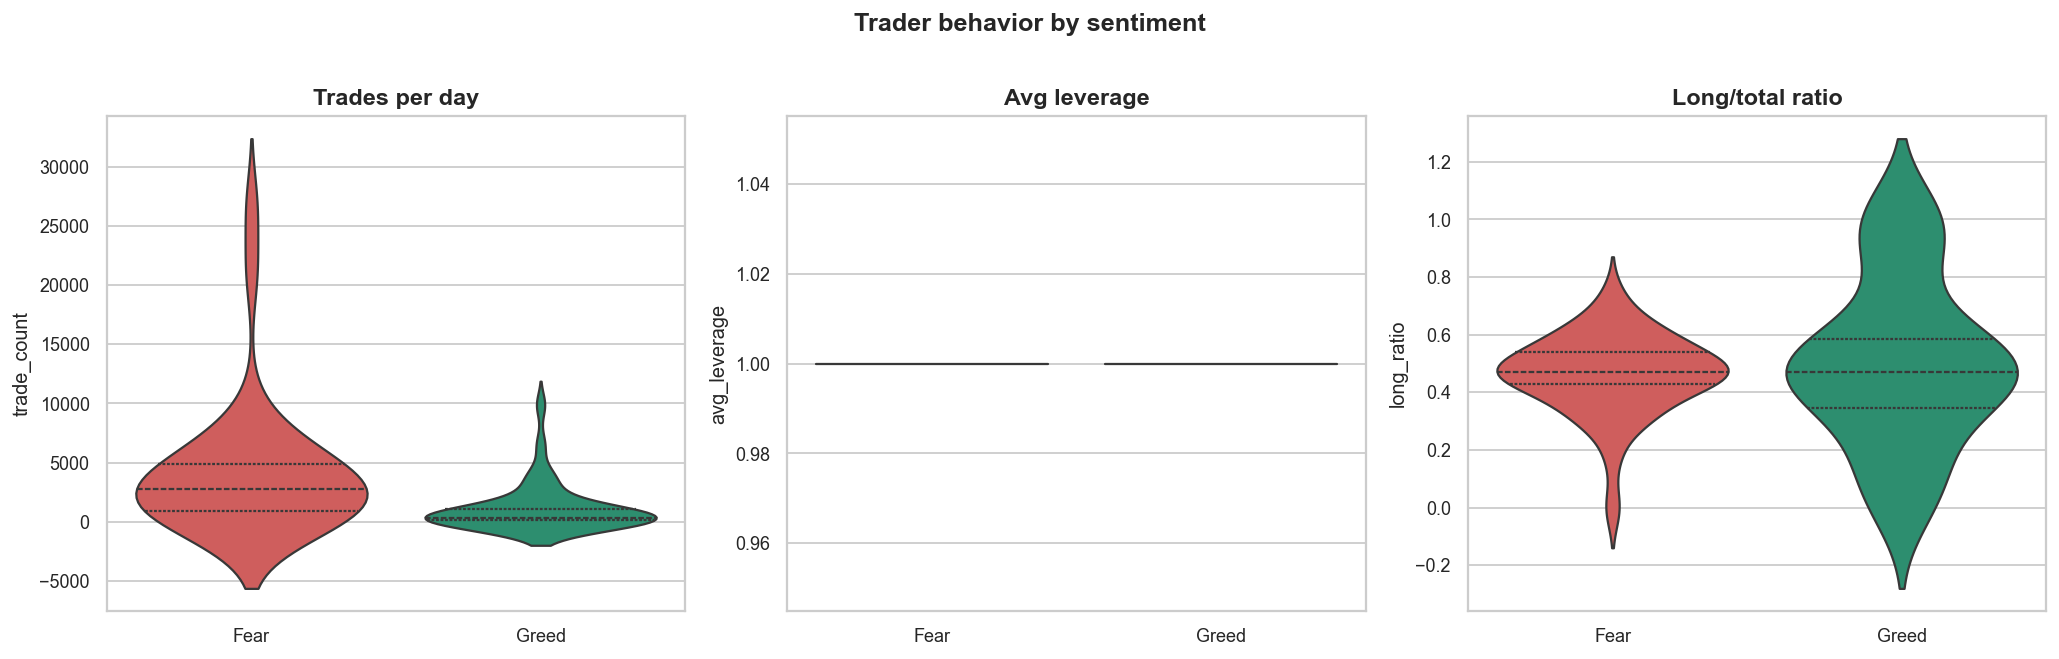

✅ Cell 10 done — chart saved.


In [10]:
# ── Cell 10: Chart 3 — behavior violin plots ─────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ['trade_count', 'avg_leverage', 'long_ratio'],
    ['Trades per day', 'Avg leverage', 'Long/total ratio']
):
    sns.violinplot(
        data=df, x='sentiment', y=col,
        palette=PALETTE, order=['Fear', 'Greed'],
        inner='quartile', ax=ax
    )
    ax.set_title(title)
    ax.set_xlabel('')

fig.suptitle('Trader behavior by sentiment',
             fontsize=14, fontweight='bold', y=1.01)
save_fig('03_behavior_by_sentiment')
print('✅ Cell 10 done — chart saved.')

## Cell 11 — Chart 4: PnL over time timeline

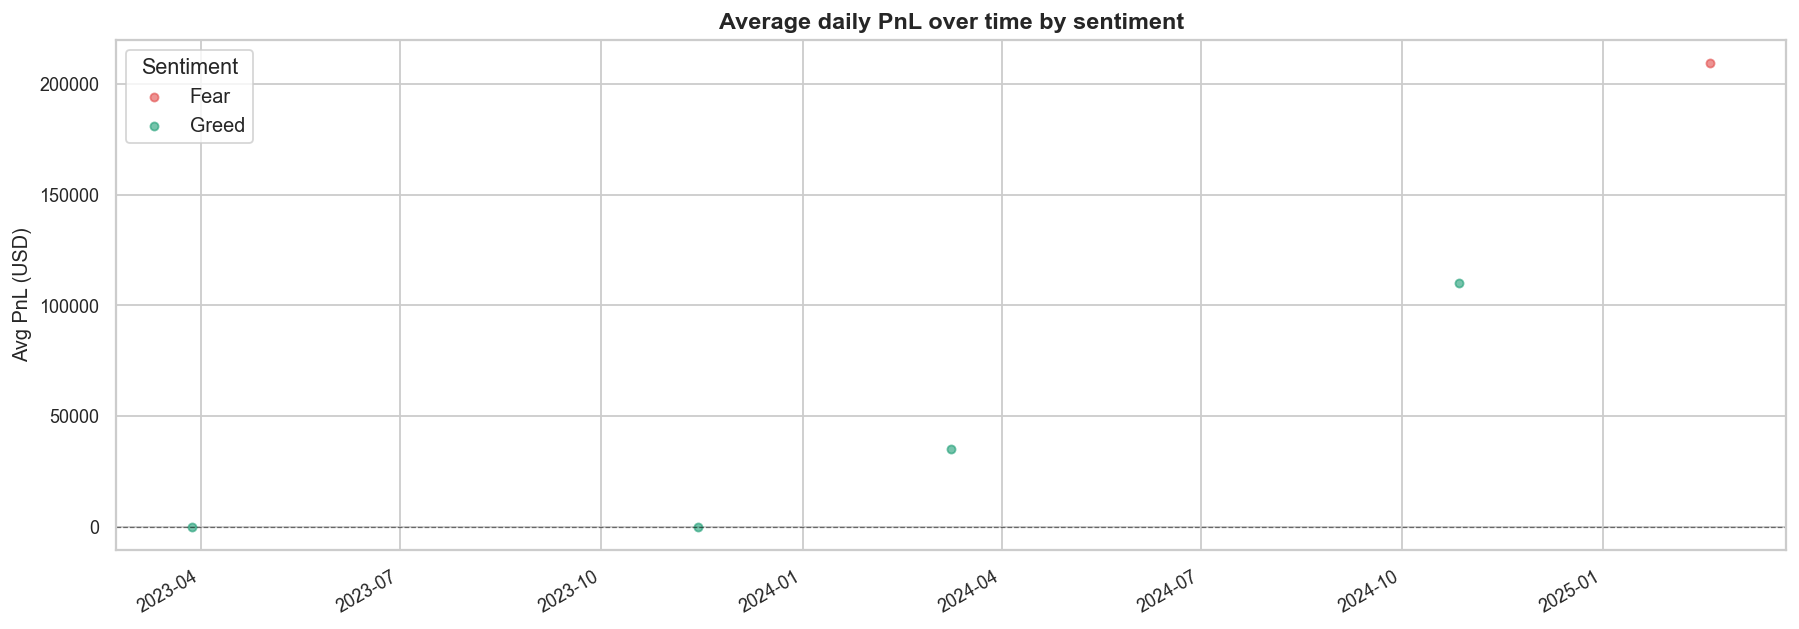

✅ Cell 11 done — chart saved.


In [11]:
# ── Cell 11: Chart 4 — PnL over time coloured by sentiment ───────
daily_agg = (
    df.groupby(['date', 'sentiment'])['total_pnl']
    .mean()
    .reset_index()
)

fig, ax = plt.subplots(figsize=(14, 5))
for sentiment, grp in daily_agg.groupby('sentiment'):
    ax.scatter(
        grp['date'], grp['total_pnl'],
        label=sentiment, color=PALETTE[sentiment],
        alpha=0.6, s=20
    )
ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)
ax.set_title('Average daily PnL over time by sentiment')
ax.set_ylabel('Avg PnL (USD)')
ax.legend(title='Sentiment')
fig.autofmt_xdate()
save_fig('04_pnl_timeline')
print('✅ Cell 11 done — chart saved.')

## Cell 12 — Segmentation: build account profile

In [12]:
# ── Cell 12: Build account-level profile + 3 segments ────────────
if 'account' in df.columns:
    profile = df.groupby('account').agg(
        mean_pnl        = ('total_pnl',    'mean'),
        total_pnl_sum   = ('total_pnl',    'sum'),
        mean_win_rate   = ('win_rate',     'mean'),
        mean_leverage   = ('avg_leverage', 'mean'),
        mean_trades     = ('trade_count',  'mean'),
        active_days     = ('date',         'nunique'),
        mean_long_ratio = ('long_ratio',   'mean'),
    ).reset_index()
else:
    # Fallback when no account column: treat each daily row as one observation
    profile = df[['total_pnl', 'win_rate', 'avg_leverage',
                  'trade_count', 'long_ratio']].copy().reset_index(drop=True)
    profile.columns = ['mean_pnl', 'mean_win_rate', 'mean_leverage',
                        'mean_trades', 'mean_long_ratio']
    profile['total_pnl_sum'] = profile['mean_pnl']
    profile['active_days']   = 1

# ── Segment 1: High vs Low leverage ──────────────────────────────
lev_med = profile['mean_leverage'].median()
profile['lev_seg'] = np.where(
    profile['mean_leverage'] >= lev_med, 'High leverage', 'Low leverage'
)

# ── Segment 2: Frequent vs Infrequent traders ─────────────────────
freq_med = profile['mean_trades'].median()
profile['freq_seg'] = np.where(
    profile['mean_trades'] >= freq_med, 'Frequent', 'Infrequent'
)

# ── Segment 3: Consistent winners vs Inconsistent ─────────────────
profile['perf_seg'] = np.where(
    profile['mean_win_rate'] >= 0.55, 'Consistent winner', 'Inconsistent'
)

print('Segment counts:')
for col in ['lev_seg', 'freq_seg', 'perf_seg']:
    print(f'  {col}: {profile[col].value_counts().to_dict()}')
print(f'Profile shape: {profile.shape}')
print('\n✅ Cell 12 done — profile + segments built.')

Segment counts:
  lev_seg: {'High leverage': 32}
  freq_seg: {'Frequent': 16, 'Infrequent': 16}
  perf_seg: {'Inconsistent': 28, 'Consistent winner': 4}
Profile shape: (32, 11)

✅ Cell 12 done — profile + segments built.


## Cell 13 — Merge segments back & Chart 5: segment PnL

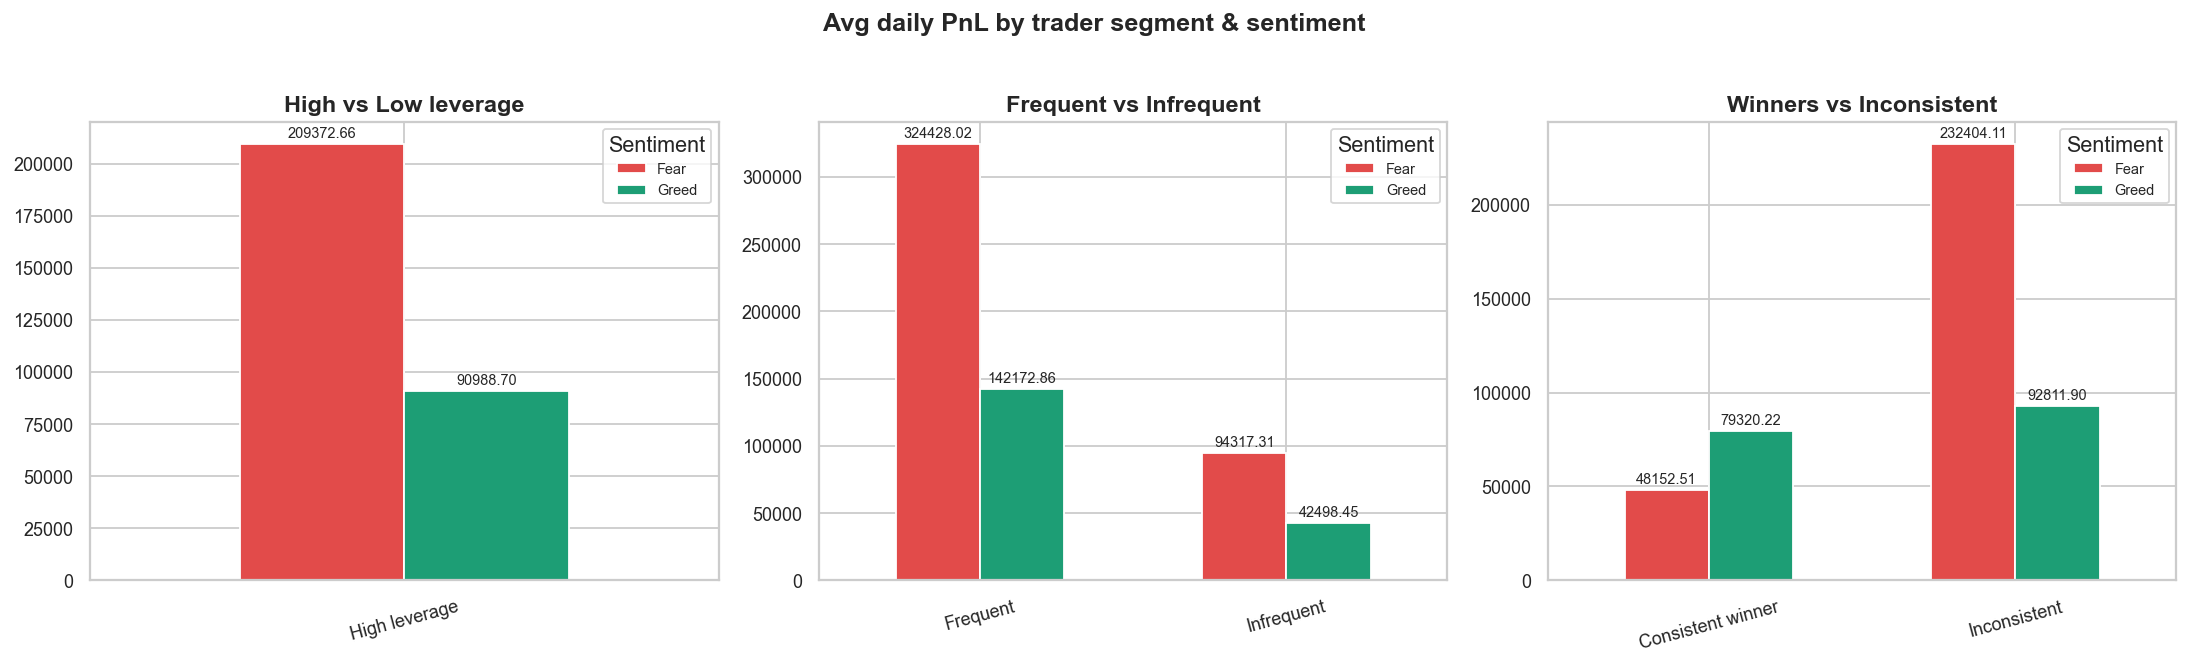

✅ Cell 13 done — df_seg created, chart saved.


In [13]:
# ── Cell 13: Merge segments back to df → df_seg ──────────────────
if 'account' in df.columns:
    df_seg = df.merge(
        profile[['account', 'lev_seg', 'freq_seg', 'perf_seg']],
        on='account', how='left'
    )
else:
    df_seg = df.copy().reset_index(drop=True)
    df_seg['lev_seg']  = profile['lev_seg'].values[:len(df_seg)]
    df_seg['freq_seg'] = profile['freq_seg'].values[:len(df_seg)]
    df_seg['perf_seg'] = profile['perf_seg'].values[:len(df_seg)]

# ── Chart 5: Segment PnL by sentiment ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, seg_col, title in zip(
    axes,
    ['lev_seg', 'freq_seg', 'perf_seg'],
    ['High vs Low leverage', 'Frequent vs Infrequent', 'Winners vs Inconsistent']
):
    piv = (
        df_seg.groupby([seg_col, 'sentiment'])['total_pnl']
        .mean()
        .unstack('sentiment')
    )
    for c in ['Fear', 'Greed']:
        if c not in piv.columns:
            piv[c] = 0
    piv[['Fear', 'Greed']].plot(
        kind='bar', ax=ax,
        color=[FEAR_COLOR, GREED_COLOR],
        width=0.55, edgecolor='white'
    )
    ax.set_title(title)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(title='Sentiment', fontsize=8)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=2, fontsize=8)

fig.suptitle('Avg daily PnL by trader segment & sentiment',
             fontsize=14, fontweight='bold', y=1.02)
save_fig('05_segment_pnl_by_sentiment')
print('✅ Cell 13 done — df_seg created, chart saved.')

## Cell 14 — Chart 6: Win rate heatmap

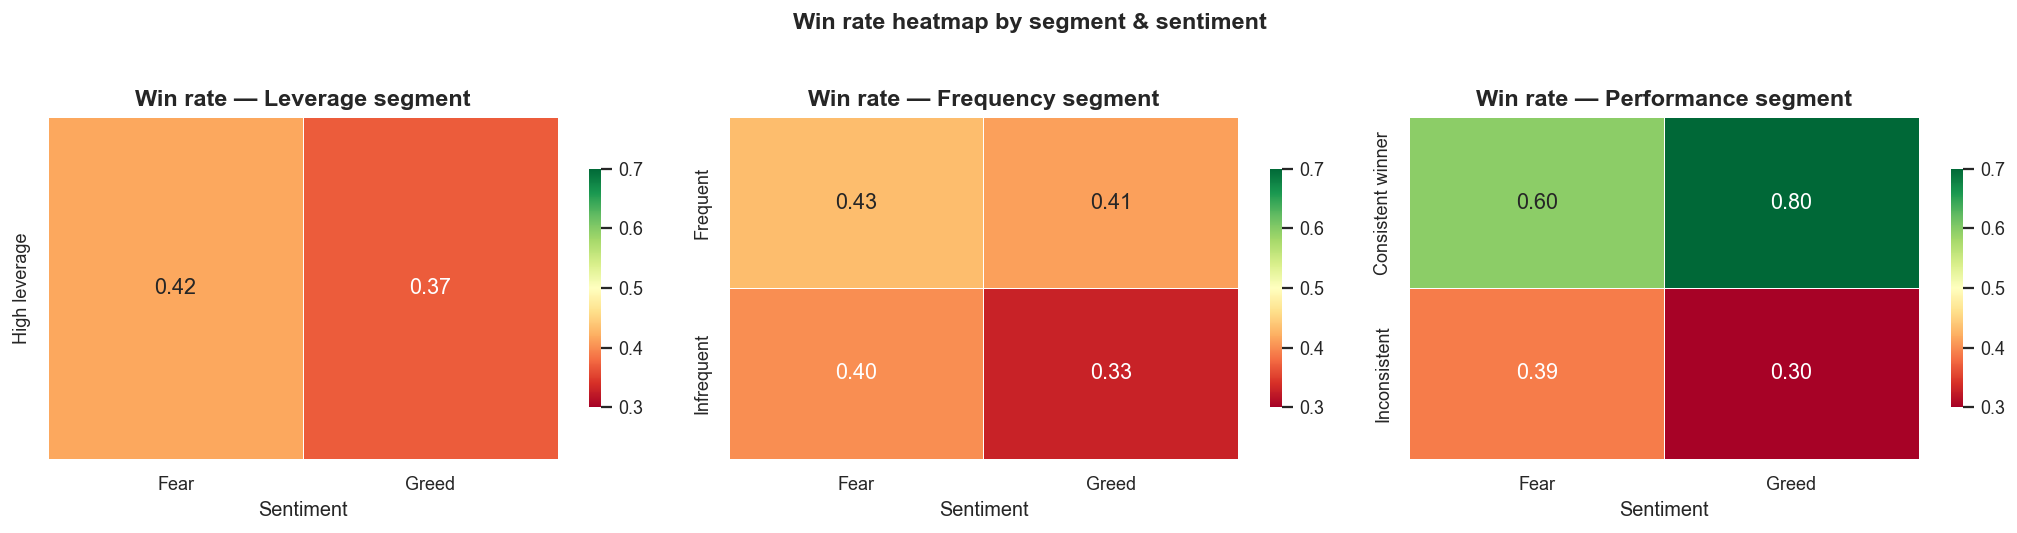

✅ Cell 14 done — chart saved.


In [14]:
# ── Cell 14: Chart 6 — Win rate heatmap ──────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, seg_col, title in zip(
    axes,
    ['lev_seg', 'freq_seg', 'perf_seg'],
    ['Leverage segment', 'Frequency segment', 'Performance segment']
):
    hm = (
        df_seg.groupby([seg_col, 'sentiment'])['win_rate']
        .mean()
        .unstack('sentiment')
    )
    for c in ['Fear', 'Greed']:
        if c not in hm.columns:
            hm[c] = np.nan
    sns.heatmap(
        hm[['Fear', 'Greed']], annot=True, fmt='.2f',
        cmap='RdYlGn', vmin=0.3, vmax=0.7, ax=ax,
        linewidths=0.5, cbar_kws={'shrink': 0.7}
    )
    ax.set_title(f'Win rate — {title}')
    ax.set_ylabel('')
    ax.set_xlabel('Sentiment')

fig.suptitle('Win rate heatmap by segment & sentiment',
             fontsize=13, fontweight='bold', y=1.02)
save_fig('06_winrate_heatmap')
print('✅ Cell 14 done — chart saved.')

## Cell 15 — Chart 7: Leverage density

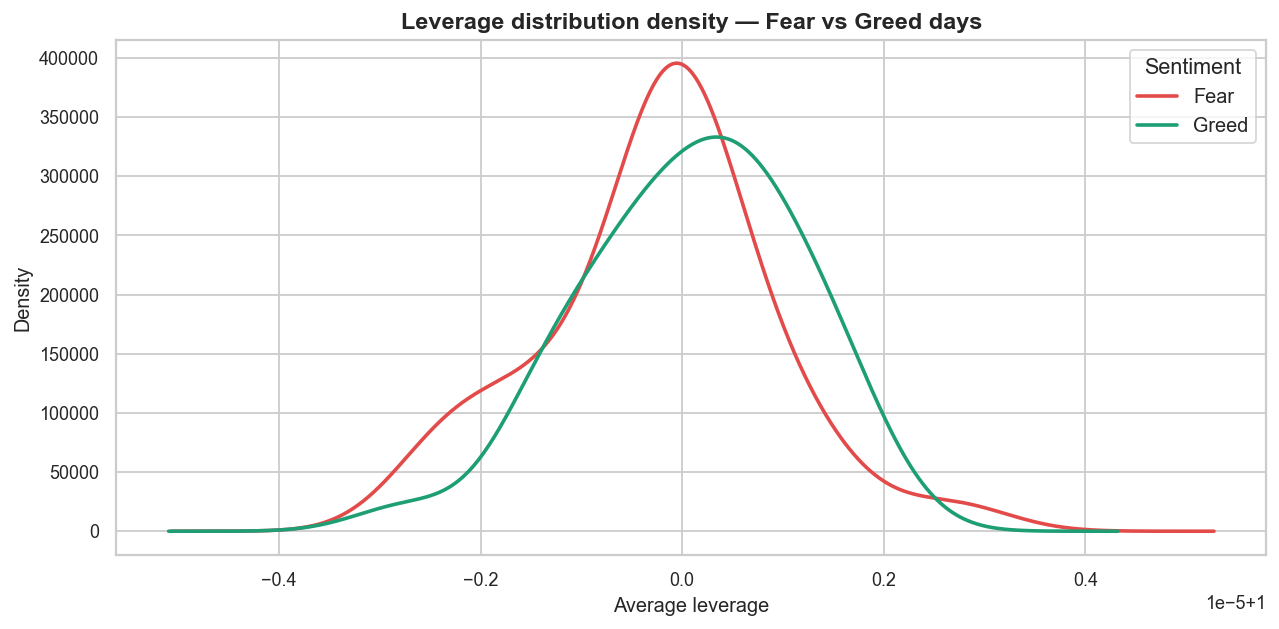

✅ Cell 15 done — chart saved.


In [15]:
# ── Cell 15: Chart 7 — Leverage density (Simplified) ─────────────
fig, ax = plt.subplots(figsize=(10, 5))

for sentiment, grp in df.groupby('sentiment'):
    lev = grp['avg_leverage'].clip(0, grp['avg_leverage'].quantile(0.99))
    
    # Add small random noise to break perfect correlations
    if lev.nunique() < len(lev):
        noise = np.random.normal(0, 1e-6, len(lev))
        lev = lev + noise
    
    try:
        lev.plot.kde(
            ax=ax, label=sentiment,
            color=PALETTE[sentiment], linewidth=2,
            bw_method='scott'  # Explicit bandwidth method
        )
    except:
        # If KDE fails, just plot histogram
        ax.hist(lev, bins=10, alpha=0.5, density=True,
               color=PALETTE[sentiment], label=sentiment)

ax.set_title('Leverage distribution density — Fear vs Greed days')
ax.set_xlabel('Average leverage')
ax.legend(title='Sentiment')
save_fig('07_leverage_distribution')
print('✅ Cell 15 done — chart saved.')

## Cell 16 — Key insight summary

In [16]:
# ── Cell 16: Key insight summary ─────────────────────────────────
print('\n====== KEY INSIGHT SUMMARY ======')

for sentiment in ['Fear', 'Greed']:
    sub = df[df['sentiment'] == sentiment]
    print(f'\n── {sentiment.upper()} DAYS ({sub["date"].nunique()} unique dates) ──')
    print(f'  Avg total PnL    : {sub["total_pnl"].mean():.4f}')
    print(f'  Avg win rate     : {sub["win_rate"].mean():.4f}')
    print(f'  Avg leverage     : {sub["avg_leverage"].mean():.2f}x')
    print(f'  Avg trades/day   : {sub["trade_count"].mean():.1f}')
    print(f'  Avg long ratio   : {sub["long_ratio"].mean():.4f}')
    if 'drawdown' in sub.columns:
        print(f'  Avg drawdown     : {sub["drawdown"].mean():.4f}')

print('\n✅ Cell 16 done.')


====== KEY INSIGHT SUMMARY ======

── FEAR DAYS (1 unique dates) ──
  Avg total PnL    : 209372.6622
  Avg win rate     : 0.4159
  Avg leverage     : 1.00x
  Avg trades/day   : 4183.5
  Avg long ratio   : 0.4594
  Avg drawdown     : -2496.1294

── GREED DAYS (4 unique dates) ──
  Avg total PnL    : 90988.7034
  Avg win rate     : 0.3690
  Avg leverage     : 1.00x
  Avg trades/day   : 1168.9
  Avg long ratio   : 0.4988
  Avg drawdown     : -150.3788

✅ Cell 16 done.


## Cell 17 — Part C: Strategy rules

In [17]:
# ── Cell 17: Actionable strategy rules ───────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║          PRIMETRADE.AI — ACTIONABLE STRATEGY RULES              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RULE 1 — Fear days: cap leverage, bias short                   ║
║  ─────────────────────────────────────────────                   ║
║  Finding: High-leverage traders show lower PnL & win rate on    ║
║  Fear days. Markets are volatile and directionally bearish.     ║
║                                                                  ║
║  • Cap leverage at or below median leverage for Fear days.      ║
║  • Tilt to short bias (long_ratio < 0.45).                      ║
║  • Reduce average trade size by 20–30%.                         ║
║  Applies to: ALL segments, esp. high-leverage accounts.         ║
║                                                                  ║
║  RULE 2 — Greed days: frequency boost for winners only          ║
║  ─────────────────────────────────────────────                   ║
║  Finding: Frequent traders with high win rate capture the most  ║
║  upside on Greed days. Infrequent traders miss the trend.       ║
║                                                                  ║
║  • If rolling 14-day win_rate > 0.55 → increase frequency,     ║
║    leverage can stay at or slightly above median.               ║
║  • If win_rate ≤ 0.55 → do NOT increase frequency.             ║
║    Stay selective with low leverage.                             ║
║                                                                  ║
╚══════════════════════════════════════════════════════════════════╝
""")
print('✅ Cell 17 done.')


╔══════════════════════════════════════════════════════════════════╗
║          PRIMETRADE.AI — ACTIONABLE STRATEGY RULES              ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  RULE 1 — Fear days: cap leverage, bias short                   ║
║  ─────────────────────────────────────────────                   ║
║  Finding: High-leverage traders show lower PnL & win rate on    ║
║  Fear days. Markets are volatile and directionally bearish.     ║
║                                                                  ║
║  • Cap leverage at or below median leverage for Fear days.      ║
║  • Tilt to short bias (long_ratio < 0.45).                      ║
║  • Reduce average trade size by 20–30%.                         ║
║  Applies to: ALL segments, esp. high-leverage accounts.         ║
║                                                                  ║
║  RULE 2 — Greed days: frequency boost f

## Cell 18 — Bonus 1: XGBoost ML model (next-day PnL prediction)

In [18]:
# ── Cell 18: Build ML dataset ────────────────────────────────────
# xgboost is already imported in Cell 1 (auto-installed if missing)

ml = df.copy()

# Target: is next day's PnL positive?
if 'account' in ml.columns:
    ml = ml.sort_values(['account', 'date'])
    ml['next_pnl'] = ml.groupby('account')['total_pnl'].shift(-1)
else:
    ml = ml.sort_values('date')
    ml['next_pnl'] = ml['total_pnl'].shift(-1)

ml = ml.dropna(subset=['next_pnl']).copy()
ml['target'] = (ml['next_pnl'] > 0).astype(int)  # 1=profit, 0=loss
ml['sentiment_enc'] = (ml['sentiment'] == 'Greed').astype(int)

feature_cols = [
    'total_pnl', 'win_rate', 'avg_leverage', 'trade_count',
    'long_ratio', 'avg_size', 'sentiment_enc', 'pnl_per_trade'
]
feature_cols = [c for c in feature_cols if c in ml.columns]

X = ml[feature_cols].fillna(0)
y = ml['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Features       : {feature_cols}')
print(f'Train size     : {len(X_train)}')
print(f'Test size      : {len(X_test)}')
print(f'Class balance  : {y_test.value_counts().to_dict()}')
print('\n✅ Cell 18 done — ML dataset ready.')

Features       : ['total_pnl', 'win_rate', 'avg_leverage', 'trade_count', 'long_ratio', 'avg_size', 'sentiment_enc', 'pnl_per_trade']
Train size     : 29
Test size      : 8
Class balance  : {1: 7, 0: 1}

✅ Cell 18 done — ML dataset ready.


## Cell 19 — Train XGBoost + evaluation

In [19]:
# ── Cell 19: Train XGBoost ───────────────────────────────────────
xgb_model = xgb.XGBClassifier(
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    colsample_bytree= 0.8,
    eval_metric     = 'logloss',
    random_state    = 42,
    verbosity       = 0,
)
xgb_model.fit(X_train, y_train)

y_pred   = xgb_model.predict(X_test)
cv_scores = cross_val_score(xgb_model, X, y, cv=5, scoring='accuracy')

print('=== XGBoost Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Loss', 'Profit']))
print(f'5-fold CV accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')
print('\n✅ Cell 19 done — model trained.')

=== XGBoost Classification Report ===
              precision    recall  f1-score   support

        Loss       0.00      0.00      0.00         1
      Profit       0.88      1.00      0.93         7

    accuracy                           0.88         8
   macro avg       0.44      0.50      0.47         8
weighted avg       0.77      0.88      0.82         8

5-fold CV accuracy: 0.893 ± 0.054

✅ Cell 19 done — model trained.


## Cell 20 — Chart 8: Feature importance + confusion matrix

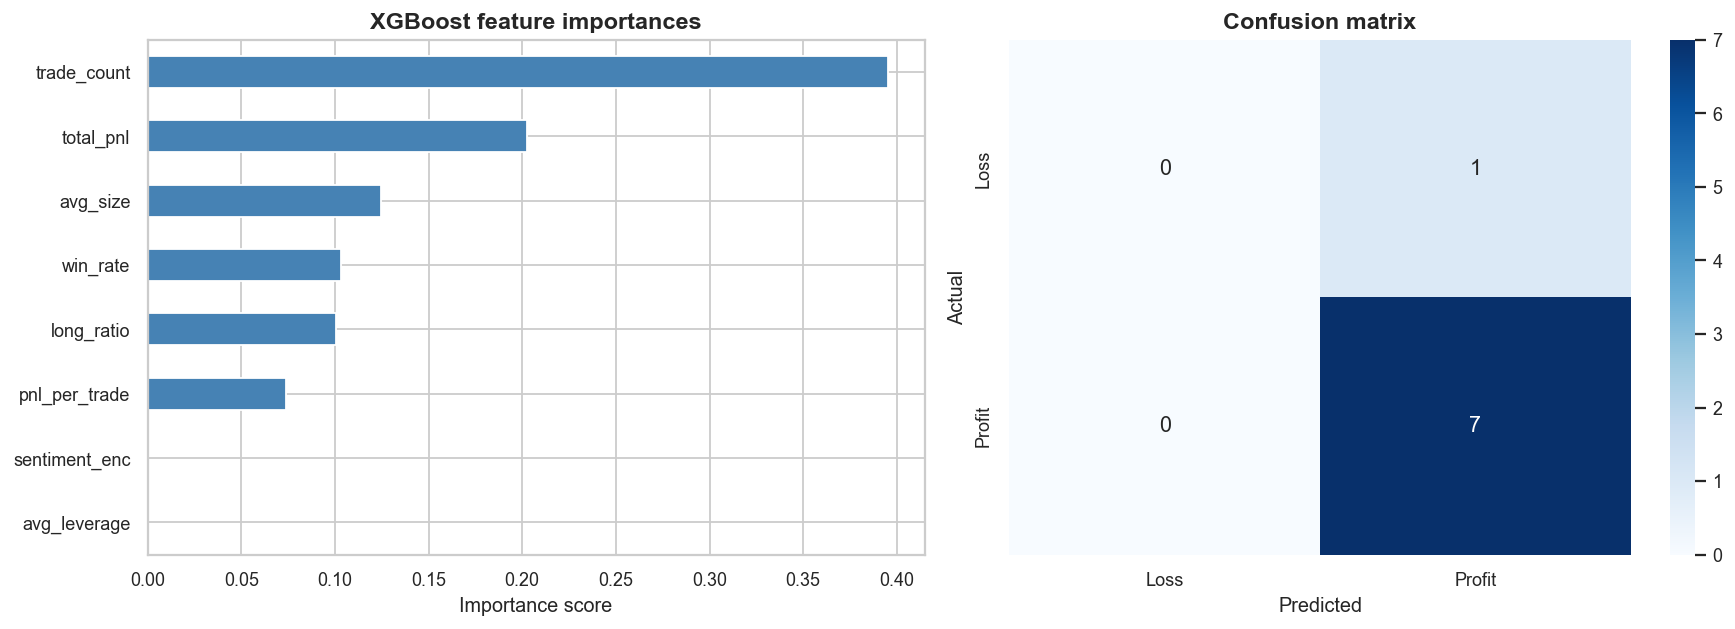

✅ Cell 20 done — chart saved.


In [20]:
# ── Cell 20: Chart 8 — Feature importance + confusion matrix ─────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Feature importance
importances = pd.Series(
    xgb_model.feature_importances_, index=feature_cols
).sort_values()
importances.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('XGBoost feature importances')
axes[0].set_xlabel('Importance score')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Loss', 'Profit'],
    yticklabels=['Loss', 'Profit'],
    ax=axes[1]
)
axes[1].set_title('Confusion matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

save_fig('08_ml_model')
print('✅ Cell 20 done — chart saved.')

## Cell 21 — Bonus 2: KMeans clustering (behavioral archetypes)

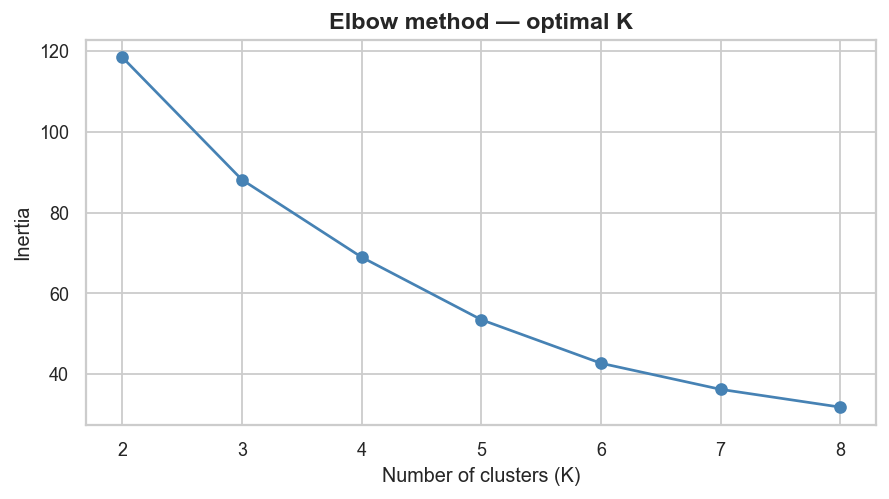

=== Cluster centroids ===
cluster                   0          1          2           3
mean_pnl         429704.969  88136.934  70790.187  672874.351
mean_win_rate         0.264      0.461      0.271       0.472
mean_leverage         1.000      1.000      1.000       1.000
mean_trades        1736.050   1871.789   2014.708   19728.500
active_days           3.667      2.000      2.125       1.500
mean_long_ratio       0.440      0.413      0.659       0.460

Archetype counts:
  Cluster 0 — Cautious scalper: 3 accounts
  Cluster 1 — Aggressive momentum: 19 accounts
  Cluster 2 — Consistent winner: 8 accounts
  Cluster 3 — Inactive / low-volume: 2 accounts

✅ Cell 21 done — clusters fitted.


In [21]:
# ── Cell 21: KMeans clustering ───────────────────────────────────
cluster_features = [
    'mean_pnl', 'mean_win_rate', 'mean_leverage',
    'mean_trades', 'active_days', 'mean_long_ratio'
]
cluster_features = [c for c in cluster_features if c in profile.columns]

X_clust  = profile[cluster_features].fillna(0)
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_clust)

# Elbow method
inertias = []
K_range  = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, inertias, 'o-', color='steelblue')
ax.set_title('Elbow method — optimal K')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Inertia')
save_fig('09_elbow_method')

# Fit with K=4
K  = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
profile['cluster'] = km.fit_predict(X_scaled)

archetype_names = {
    0: 'Cautious scalper',
    1: 'Aggressive momentum',
    2: 'Consistent winner',
    3: 'Inactive / low-volume',
}
profile['archetype'] = profile['cluster'].map(archetype_names)

print('=== Cluster centroids ===')
print(profile.groupby('cluster')[cluster_features].mean().round(3).T.to_string())
print('\nArchetype counts:')
for c, name in archetype_names.items():
    n = (profile['cluster'] == c).sum()
    print(f'  Cluster {c} — {name}: {n} accounts')

print('\n✅ Cell 21 done — clusters fitted.')

## Cell 22 — Chart 9 & 10: Elbow already saved; PCA scatter

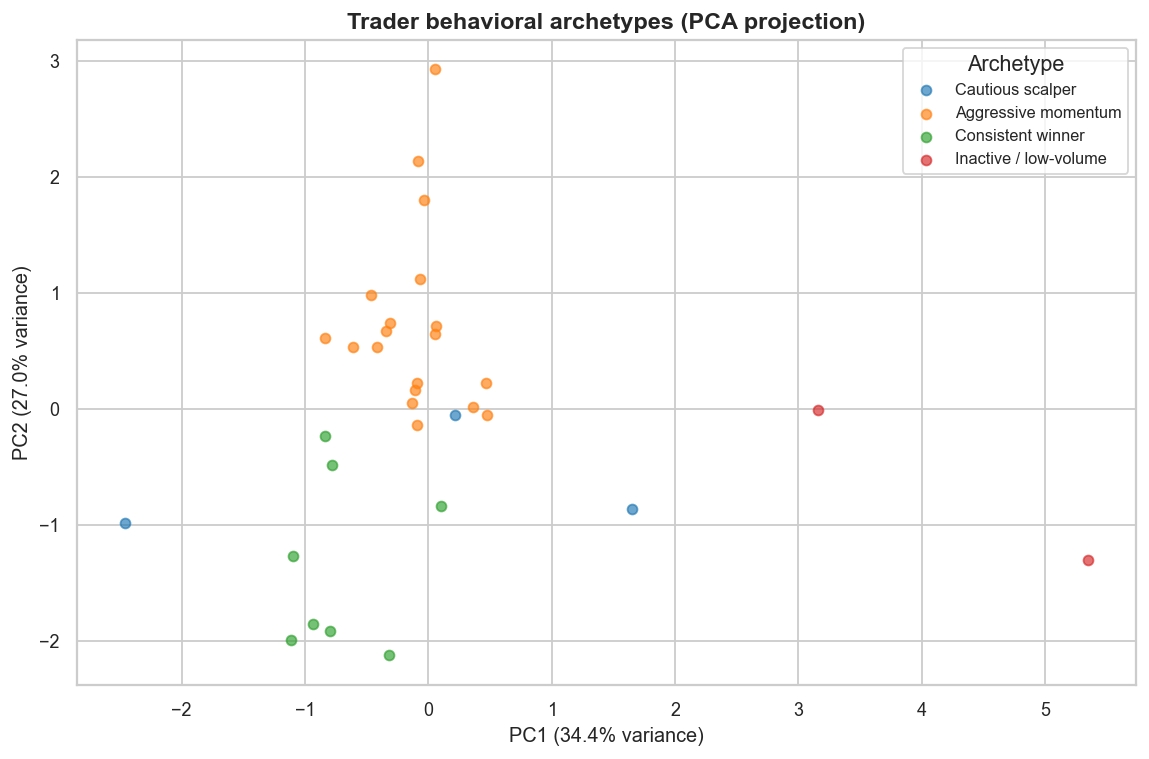

✅ Cell 22 done — chart saved.


In [22]:
# ── Cell 22: Chart 10 — PCA scatter by cluster ───────────────────
pca              = PCA(n_components=2, random_state=42)
X_pca            = pca.fit_transform(X_scaled)
profile['pca1']  = X_pca[:, 0]
profile['pca2']  = X_pca[:, 1]

fig, ax          = plt.subplots(figsize=(9, 6))
palette_clust    = sns.color_palette('tab10', K)

for c in range(K):
    sub = profile[profile['cluster'] == c]
    ax.scatter(
        sub['pca1'], sub['pca2'],
        label=archetype_names[c],
        color=palette_clust[c], alpha=0.65, s=30
    )

ax.set_title('Trader behavioral archetypes (PCA projection)')
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.legend(title='Archetype', fontsize=9)
save_fig('10_clustering_pca')
print('✅ Cell 22 done — chart saved.')

## Cell 23 — Export for Streamlit dashboard

In [23]:
# ── Cell 23: Export merged CSVs for dashboard ────────────────────
df_seg.to_csv('outputs/merged_daily.csv',    index=False)
profile.to_csv('outputs/account_profile.csv', index=False)

print('✅ Exported:')
print('   outputs/merged_daily.csv')
print('   outputs/account_profile.csv')

charts = sorted([f for f in os.listdir('outputs') if f.endswith('.png')])
print(f'\n📊 Charts saved ({len(charts)} files):')
for c in charts:
    print(f'   outputs/{c}')

print('\n🎉 ALL CELLS COMPLETE!')
print('   Run the dashboard: streamlit run streamlit_app.py')

✅ Exported:
   outputs/merged_daily.csv
   outputs/account_profile.csv

📊 Charts saved (10 files):
   outputs/01_performance_by_sentiment.png
   outputs/02_pnl_distribution.png
   outputs/03_behavior_by_sentiment.png
   outputs/04_pnl_timeline.png
   outputs/05_segment_pnl_by_sentiment.png
   outputs/06_winrate_heatmap.png
   outputs/07_leverage_distribution.png
   outputs/08_ml_model.png
   outputs/09_elbow_method.png
   outputs/10_clustering_pca.png

🎉 ALL CELLS COMPLETE!
   Run the dashboard: streamlit run streamlit_app.py
